# Final Results: HBN (Healthy Brain Network)

> **Reproducibility note (read before running):** this notebook is one of a set of
> `0*_*.ipynb` notebooks split out of the original `compiled_results_analysis.ipynb`
> for the publication reproducibility bundle, meant to be run with the repo root (`task_dim/`) as
> the working directory. Each notebook is self-contained (re-loads its own
> inputs rather than relying on variables from other notebooks). A global `SEED = 42` is set at
> the top of the setup cell so every resampling/permutation step below is deterministic.
>
> **Inputs used here are pre-computed.** Where a cell loads a CSV/NIfTI file, a comment states
> which upstream script produced it. A few inputs this notebook depends on
> (`compiled/info/combined_participant_info.csv`, `compiled/results/*_compiled_results.csv`,
> `compiled/results/combined_corrs.csv`, `compiled/results/combined_corr_analyses.csv`) 

In [6]:
import numpy as np
import pandas as pd
import os, sys, glob
import matplotlib.pyplot as plt
import seaborn as sns
import nibabel as nib
import scipy
import scipy.stats as stats
from scipy.spatial.distance import cdist, pdist, squareform
from scipy.stats import ttest_rel, ttest_ind, wilcoxon, spearmanr
import nilearn
from nilearn import plotting, image, datasets
from nilearn.maskers import NiftiMasker
from nilearn.mass_univariate import permuted_ols
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.anova import anova_lm
import matplotlib.gridspec as gridspec
from patsy import dmatrix
from sklearn.utils import resample
import pingouin as pg
from matplotlib.patches import Patch
from matplotlib import rcParams
import matplotlib.ticker as mticker
from scipy.stats import gaussian_kde

# Repo-local helper modules (see CLAUDE.md for the dataset-abstraction pattern)
import plotting_helpers as helper          # surface plots, colormaps, dataset colors
import stats_helpers as stats_helpers      # permutation tests, (parcelwise/LME) regression, FDR correction
import parcelwise_regressions as pwr       # run_regression_analyses, join_results_participant_info, clean_difference_dataframe
import hbn_config as hc                    # hc.AGE_BINS / hc.HBN_AGE_GROUPS used for HBN age binning

rcParams['pdf.fonttype'] = 42
rcParams['ps.fonttype'] = 42

PLOT_DIR = 'compiled/plots'
os.makedirs(PLOT_DIR, exist_ok=True)
ISC_CMAP = 'OrRd'
ID_CMAP = helper.custom_blues_cmap()
dataset_colors = helper.dataset_colors('all')

# Global seed: makes every unseeded resample/permutation call below reproducible.
SEED = 42
np.random.seed(SEED)

In [7]:
# Common helper functions -- now defined once in plotting_helpers.py / stats_helpers.py
# (previously redefined identically in every final_results notebook; see REPRODUCIBILITY.md).
from plotting_helpers import (
    expand_parcellation_to_volume,  # parcel-array -> 3D volume
    load_atlas, get_region_order,   # Schaefer-400 atlas + region label order
    get_average_results, reorder_region_names,  # average/reindex per-region scores
)
from stats_helpers import lme_fit_summary  # MixedLM fit diagnostics (R^2, ICC, AIC/BIC)

## Load results and participant info

In [8]:
# INPUT: compiled/results/hbn_compiled_results.csv (see REPRODUCIBILITY.md)
# INPUT: HBN/basic_cohort_info.csv -- produced by hbn_config.py
atlas_img, atlas_labels = load_atlas()
results_df_hbn = pd.read_csv('compiled/results/hbn_compiled_results.csv')

par_df_hbn = pd.read_csv('HBN/basic_cohort_info.csv', index_col=1)
par_df_hbn['include_both_tasks'] = [
    1 if (int(np.isnan(row.movie_FD)) + int(np.isnan(row.rest_FD)) + int(row.cleaning_done == 0) == 0) else 0
    for _, row in par_df_hbn.iterrows()]
par_df_hbn = par_df_hbn[par_df_hbn['include_both_tasks'] == 1]
REGION_ORDER_HBN = results_df_hbn['region_name'].values[:400]
print(f"HBN subjects: {par_df_hbn.shape[0]}, results rows: {results_df_hbn.shape[0]}")

def age_group_hbn(age):
    # hc.AGE_BINS / hc.HBN_AGE_GROUPS come from hbn_config.py
    for i in range(len(hc.AGE_BINS)):
        if age < hc.AGE_BINS[i]:
            return hc.HBN_AGE_GROUPS[i]
    return None

def get_mean_fd(subject, task):
    fd_col = 'movie_FD' if task == 'movieTP' else 'rest_FD'
    if subject in par_df_hbn.index and fd_col in par_df_hbn.columns:
        return par_df_hbn.loc[subject, fd_col], par_df_hbn.loc[subject, 'sex']
    else:
        return np.nan

[get_dataset_dir] Dataset found in /Users/elb/nilearn_data/schaefer_2018
HBN subjects: 528, results rows: 633600


## ANOVA: AgeGroup x task for IDE

In [9]:
results_df_hbn['log_age'] = np.log(results_df_hbn['age_months'] + 1)
# Use a separate variable for the IDE-only subset -- the original notebook overwrote
# results_df_hbn here, which silently broke the later ISC-only filter in the next cell
# (it would return zero rows, since results_df_hbn no longer had any ISC rows).
results_df_hbn_ide = results_df_hbn[results_df_hbn['measure'] == 'TPHATE_DiffOp_IDE']
temp_hbn = results_df_hbn_ide.groupby(['subject_id', 'task', 'age_months', '_age_raw']).mean(numeric_only=True).reset_index()

vals = np.array([get_mean_fd(row['subject_id'], row['task']) for _, row in temp_hbn.iterrows()])
temp_hbn['sex'] = vals[:, 1]
temp_hbn['mean_FD'] = vals[:, 0]
temp_hbn['mean_FD'] = temp_hbn['mean_FD'].astype(float)
temp_hbn['task'] = temp_hbn['task'].astype('category')
temp_hbn['sex'] = temp_hbn['sex'].astype('category')

Q = 6  # number of (roughly) equal-sized age bins
bin_edges = pd.qcut(temp_hbn['_age_raw'], q=Q, retbins=True)[1]
bin_labels = []
for i in range(len(bin_edges) - 1):
    lower = int(bin_edges[i]); upper = int(bin_edges[i + 1])
    bin_labels.append(f'{lower}-{upper}')
temp_hbn['AgeGroup_Binned'] = pd.qcut(temp_hbn['_age_raw'], q=Q, retbins=False, labels=bin_labels)
print("Age bins and their ranges:")
for label in bin_labels:
    bin_range = temp_hbn[temp_hbn['AgeGroup_Binned'] == label]['_age_raw'].agg(['min', 'max'])
    count = len(temp_hbn[temp_hbn['AgeGroup_Binned'] == label]) / 2
    print(f"{label}: n={count}, {bin_range['min']:.1f} - {bin_range['max']:.1f} years")

temp_hbn['AgeGroup_Binned'] = temp_hbn['AgeGroup_Binned'].astype('category')

model = smf.ols('score ~ age_months * C(task) + sex + mean_FD', data=temp_hbn).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(model.summary())
print(anova_table)

Age bins and their ranges:
5-8: n=88.0, 5.2 - 8.7 years
8-10: n=88.0, 8.7 - 10.2 years
10-11: n=88.0, 10.2 - 11.9 years
11-13: n=88.0, 11.9 - 13.8 years
13-16: n=88.0, 13.8 - 16.2 years
16-21: n=88.0, 16.2 - 21.9 years
                            OLS Regression Results                            
Dep. Variable:                  score   R-squared:                       0.382
Model:                            OLS   Adj. R-squared:                  0.379
Method:                 Least Squares   F-statistic:                     108.2
Date:                Thu, 30 Jul 2026   Prob (F-statistic):          4.10e-106
Time:                        10:34:29   Log-Likelihood:                -2317.4
No. Observations:                1056   AIC:                             4649.
Df Residuals:                    1049   BIC:                             4683.
Df Model:                           6                                         
Covariance Type:            nonrobust                                 

## Mean ISC/IDE/FD by age group, and vs. age (HBN only)

/var/folders/1f/s3_5gwyj4j3c18swys7lqz4w0000gn/T/ipykernel_62033/1757787158.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=single_isc_hbn, x='AgeGroup_Binned', y='score', ax=ax, order=bin_labels, palette='Set3', alpha=0.6, edgecolor='black')
/var/folders/1f/s3_5gwyj4j3c18swys7lqz4w0000gn/T/ipykernel_62033/1757787158.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=single_isc_hbn, x='AgeGroup_Binned', y='score', ax=ax, order=bin_labels, size=4, alpha=0.7, palette='Set3')
/var/folders/1f/s3_5gwyj4j3c18swys7lqz4w0000gn/T/ipykernel_62033/1757787158.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x

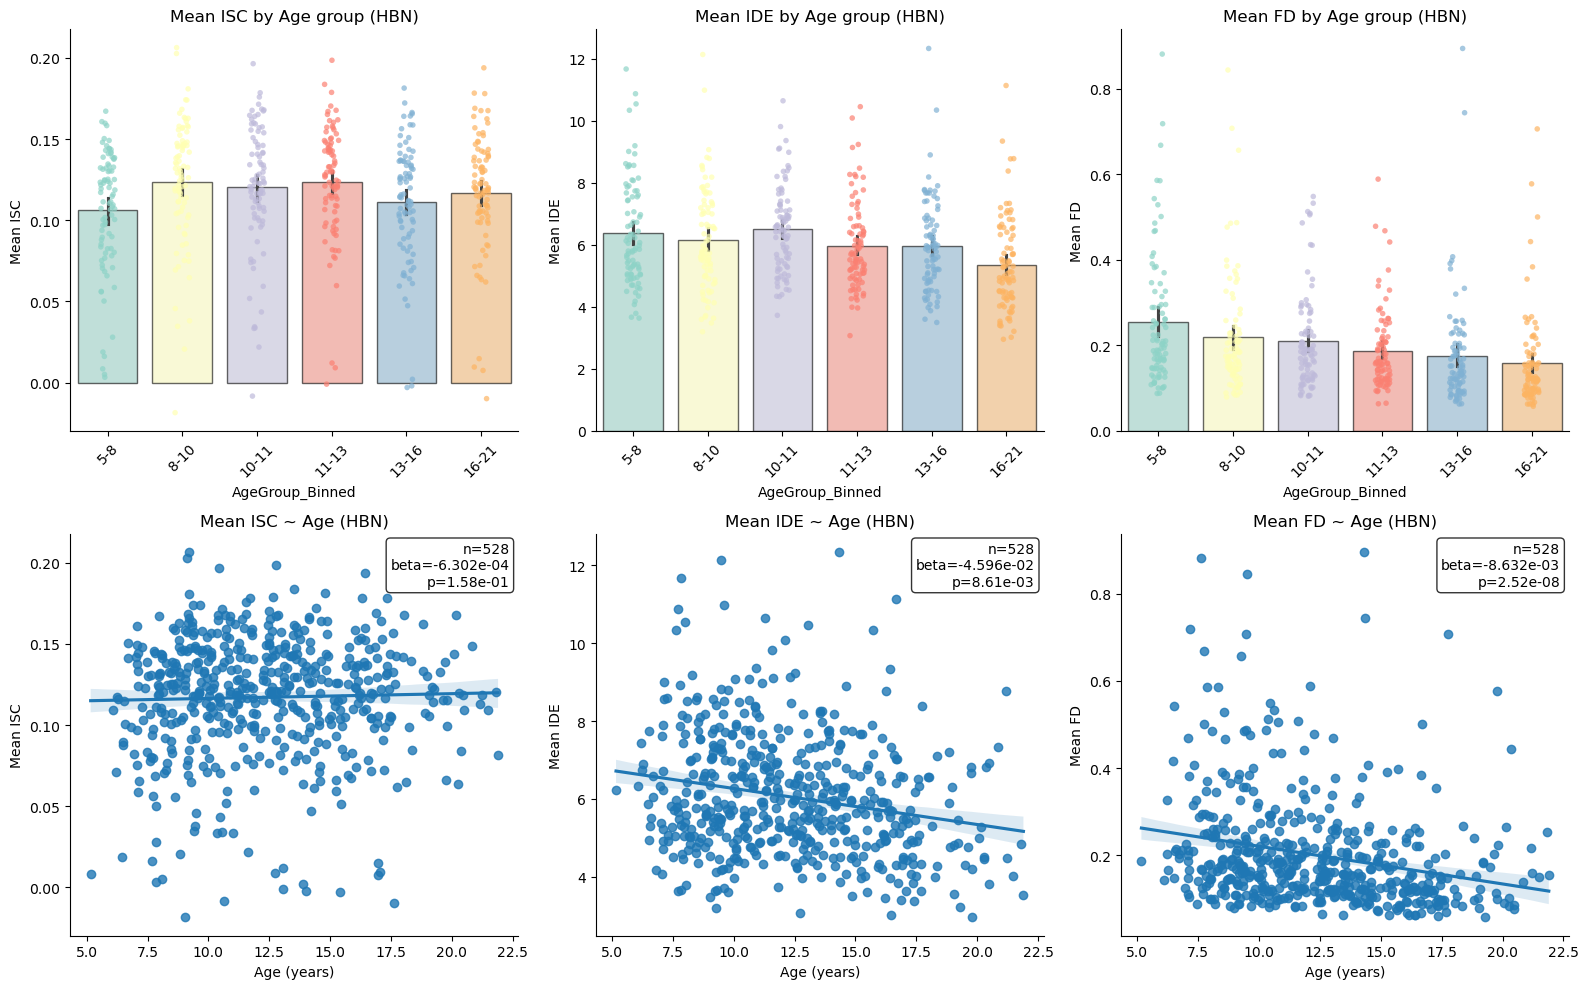

In [10]:
df_regional_isc_hbn = results_df_hbn[(results_df_hbn['task'] == 'movieTP') & (results_df_hbn['measure'] == 'ISC')].copy()
df_regional_isc_hbn['age_y'] = df_regional_isc_hbn['age_months'] / 12
single_isc_hbn = df_regional_isc_hbn.groupby('subject_id').mean(numeric_only=True).reset_index()
single_isc_hbn['AgeGroup_Binned'] = pd.qcut(single_isc_hbn['_age_raw'], q=Q, retbins=False, labels=bin_labels)
single_isc_hbn['mean_FD'] = single_isc_hbn['subject_id'].map(par_df_hbn['movie_FD'])
single_isc_hbn['sex'] = single_isc_hbn['subject_id'].map(par_df_hbn['sex'])

df_regional_ide_hbn = results_df_hbn[(results_df_hbn['task'] == 'movieTP') & (results_df_hbn['measure'] == 'TPHATE_DiffOp_IDE')].copy()
df_regional_ide_hbn['age_y'] = df_regional_ide_hbn['age_months'] / 12
single_ide_hbn = df_regional_ide_hbn.groupby('subject_id').mean(numeric_only=True).reset_index()
single_ide_hbn['AgeGroup_Binned'] = pd.qcut(single_ide_hbn['_age_raw'], q=Q, retbins=False, labels=bin_labels)
single_ide_hbn['mean_FD'] = single_ide_hbn['subject_id'].map(par_df_hbn['movie_FD'])
single_ide_hbn['sex'] = single_ide_hbn['subject_id'].map(par_df_hbn['sex'])

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

ax = axes[0, 0]
sns.barplot(data=single_isc_hbn, x='AgeGroup_Binned', y='score', ax=ax, order=bin_labels, palette='Set3', alpha=0.6, edgecolor='black')
sns.stripplot(data=single_isc_hbn, x='AgeGroup_Binned', y='score', ax=ax, order=bin_labels, size=4, alpha=0.7, palette='Set3')
ax.set_ylabel('Mean ISC'); ax.set_title('Mean ISC by Age group (HBN)'); ax.tick_params(axis='x', rotation=45)

ax = axes[0, 1]
sns.barplot(data=single_ide_hbn, x='AgeGroup_Binned', y='score', ax=ax, order=bin_labels, palette='Set3', alpha=0.6, edgecolor='black')
sns.stripplot(data=single_ide_hbn, x='AgeGroup_Binned', y='score', ax=ax, order=bin_labels, size=4, alpha=0.7, palette='Set3')
ax.set_ylabel('Mean IDE'); ax.set_title('Mean IDE by Age group (HBN)'); ax.tick_params(axis='x', rotation=45)

ax = axes[1, 0]
sns.regplot(data=single_isc_hbn, x='age_y', y='score', ax=ax)
ols1_hbn = smf.ols('score ~ age_y + mean_FD', data=single_isc_hbn).fit()
beta_age_isc_hbn = ols1_hbn.params['age_y']; p_age_isc_hbn = ols1_hbn.pvalues['age_y']
ax.text(0.98, 0.98, f'n={len(single_isc_hbn)}\nbeta={beta_age_isc_hbn:.3e}\np={p_age_isc_hbn:.2e}',
    transform=ax.transAxes, ha='right', va='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.set_xlabel('Age (years)'); ax.set_ylabel('Mean ISC'); ax.set_title('Mean ISC ~ Age (HBN)')

ax = axes[1, 1]
sns.regplot(data=single_ide_hbn, x='age_y', y='score', ax=ax)
ols2_hbn = smf.ols('score ~ age_y + mean_FD', data=single_ide_hbn).fit()
beta_age_id_hbn = ols2_hbn.params['age_y']; p_age_id_hbn = ols2_hbn.pvalues['age_y']
ax.text(0.98, 0.98, f'n={len(single_ide_hbn)}\nbeta={beta_age_id_hbn:.3e}\np={p_age_id_hbn:.2e}',
    transform=ax.transAxes, ha='right', va='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.set_xlabel('Age (years)'); ax.set_ylabel('Mean IDE'); ax.set_title('Mean IDE ~ Age (HBN)')

ax = axes[0, 2]
sns.barplot(data=single_ide_hbn, x='AgeGroup_Binned', y='mean_FD', ax=ax, order=bin_labels, palette='Set3', alpha=0.6, edgecolor='black')
sns.stripplot(data=single_ide_hbn, x='AgeGroup_Binned', y='mean_FD', ax=ax, order=bin_labels, size=4, alpha=0.7, palette='Set3')
ax.set_ylabel('Mean FD'); ax.set_title('Mean FD by Age group (HBN)'); ax.tick_params(axis='x', rotation=45)

ax = axes[1, 2]
sns.regplot(data=single_isc_hbn, x='age_y', y='mean_FD', ax=ax)
ols3_hbn = smf.ols('mean_FD ~ age_y', data=single_isc_hbn).fit()
beta_age_fd_hbn = ols3_hbn.params['age_y']; p_age_fd_hbn = ols3_hbn.pvalues['age_y']
ax.text(0.98, 0.98, f'n={len(single_isc_hbn)}\nbeta={beta_age_fd_hbn:.3e}\np={p_age_fd_hbn:.2e}',
    transform=ax.transAxes, ha='right', va='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.set_xlabel('Age (years)'); ax.set_ylabel('Mean FD'); ax.set_title('Mean FD ~ Age (HBN)')

sns.despine(); plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/hbn_means_by_age.pdf', format='pdf', transparent=True)
plt.show()
par_df_hbn = par_df_hbn.reset_index()

## Demographics and motion

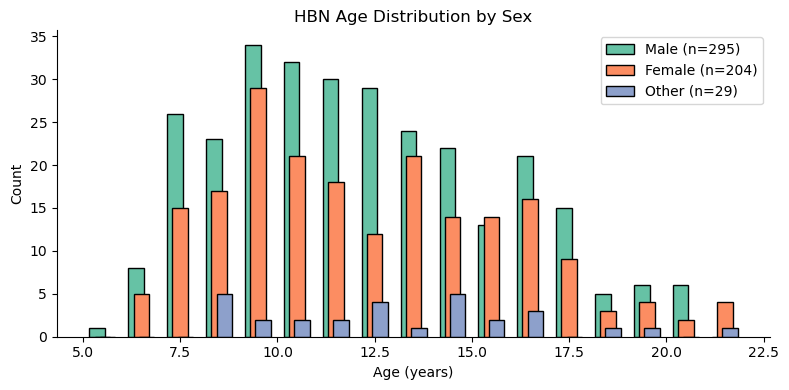

In [11]:
# HBN: demographics -- age distribution by sex and site
bins = np.arange(np.floor(par_df_hbn['age'].min()), np.ceil(par_df_hbn['age'].max()) + 1)
bin_centers = (bins[:-1] + bins[1:]) / 2
sexes = ['Male', 'Female', 'Other']
set2 = sns.color_palette('Set2')
palette_sex = {s: set2[i] for i, s in enumerate(sexes)}

ages_m = par_df_hbn[par_df_hbn['sex'] == 'Male']['age'].dropna()
ages_f = par_df_hbn[par_df_hbn['sex'] == 'Female']['age'].dropna()
ages_o = par_df_hbn[~par_df_hbn['sex'].isin(['Male', 'Female'])]['age'].dropna()
counts_m, _ = np.histogram(ages_m, bins=bins)
counts_f, _ = np.histogram(ages_f, bins=bins)
counts_o, _ = np.histogram(ages_o, bins=bins)

plt.figure(figsize=(8, 4))
width = 0.4
plt.bar(bin_centers - width/3, counts_m, width=width, color=palette_sex['Male'], edgecolor='black', label=f"Male (n={len(ages_m)})")
plt.bar(bin_centers, counts_f, width=width, color=palette_sex['Female'], edgecolor='black', label=f"Female (n={len(ages_f)})")
plt.bar(bin_centers + width/3, counts_o, width=width, color=palette_sex['Other'], edgecolor='black', label=f"Other (n={len(ages_o)})")
plt.xlabel('Age (years)'); plt.ylabel('Count'); plt.title('HBN Age Distribution by Sex')
plt.legend(); sns.despine(); plt.tight_layout(); plt.show()

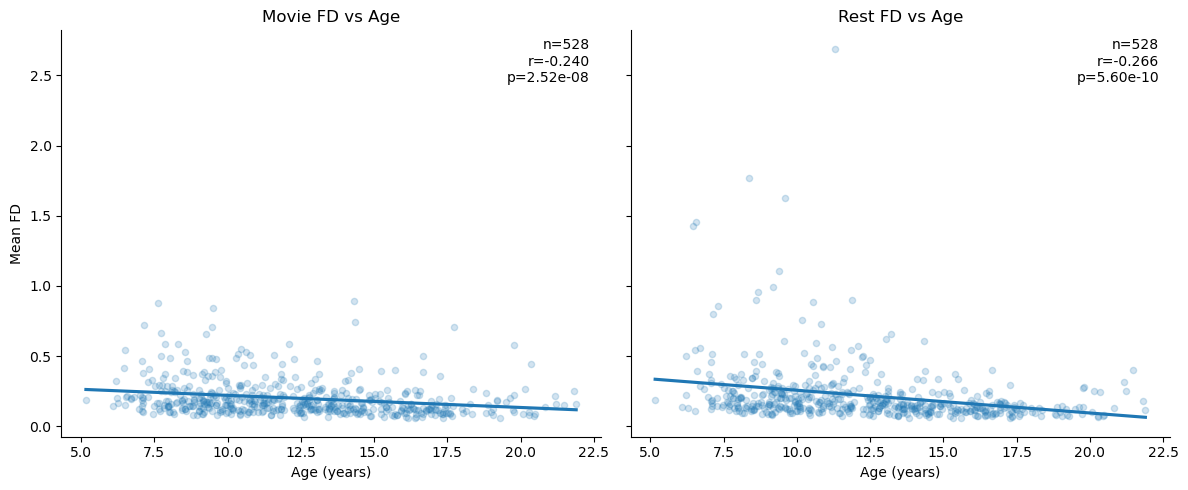

In [12]:
# HBN: motion -- FD vs Age for movie and rest
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
for i, (metric, title) in enumerate([('movie_FD', 'Movie FD vs Age'), ('rest_FD', 'Rest FD vs Age')]):
    ax = axes[i]
    mask = par_df_hbn[['age', metric]].notnull().all(axis=1)
    x, y = par_df_hbn.loc[mask, 'age'], par_df_hbn.loc[mask, metric]
    sns.regplot(data=par_df_hbn.loc[mask], x='age', y=metric, ax=ax,
                scatter_kws={'s': 20, 'alpha': 0.2}, ci=None)
    r_val, p_val = stats.pearsonr(x, y)
    ax.text(0.98, 0.98, f'n={mask.sum()}\nr={r_val:.3f}\np={p_val:.2e}',
            transform=ax.transAxes, ha='right', va='top',
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
    ax.set_title(title); ax.set_xlabel('Age (years)'); ax.set_ylabel('Mean FD' if i == 0 else '')
sns.despine(); plt.tight_layout(); plt.show()

## Build parcelwise difference dataframe (rest − movie IDE, + ISC, + age/motion)

In [13]:
# Builds HBN/parcelwise_difference_ISC_IDE.csv from source.
# Uses parcelwise_regressions.join_results_participant_info + clean_difference_dataframe.
participant_df_hbn = pd.read_csv('HBN/basic_cohort_info.csv')
temp = results_df_hbn[results_df_hbn['measure'] == 'ISC']

dataframe_hbn = pwr.join_results_participant_info(results_df_hbn, participant_df_hbn, 'hbn')
dataframe_hbn = dataframe_hbn[dataframe_hbn['measure'] == 'TPHATE_DiffOp_IDE']
dataframe_hbn = dataframe_hbn.rename({"sex_x": 'sex', '_age_raw': 'Age'}, axis=1)
# clean_difference_dataframe requires an AgeGroup column -- not created by the original
# (commented-out) notebook code, added here using age_group_hbn() defined above.
dataframe_hbn['AgeGroup'] = dataframe_hbn['Age'].apply(age_group_hbn)
difference_df = pwr.clean_difference_dataframe(dataframe_hbn)
difference_df['ISC'] = difference_df.merge(temp, on=['subject_id', 'region_name'])['score']
difference_df.to_csv('HBN/parcelwise_difference_ISC_IDE.csv', index=False)
difference_df.head()

,subject_id,region_name,rest_score,movie_score,AgeGroup,RestMovieDiff,movie_FD,rest_FD,Age,sex,session,ISC
0,sub-NDARAA948VFH,17Networks_LH_ContA_Cingm_1,3.0,3.0,U_08,0.0,0.10056,0.196904,7.98266,Female,HBNsiteRU,0.098805
1,sub-NDARAA948VFH,17Networks_LH_ContA_IPS_1,19.0,15.0,U_08,4.0,0.10056,0.196904,7.98266,Female,HBNsiteRU,0.237495
2,sub-NDARAA948VFH,17Networks_LH_ContA_IPS_2,9.0,6.0,U_08,3.0,0.10056,0.196904,7.98266,Female,HBNsiteRU,0.268342
3,sub-NDARAA948VFH,17Networks_LH_ContA_IPS_3,19.0,11.0,U_08,8.0,0.10056,0.196904,7.98266,Female,HBNsiteRU,0.264406
4,sub-NDARAA948VFH,17Networks_LH_ContA_IPS_4,17.0,12.0,U_08,5.0,0.10056,0.196904,7.98266,Female,HBNsiteRU,0.190111


## AgeGroup difference dataframe (coarse 4-bin age groups) and surface grid

In [14]:
def get_age_groupings_hbn(age):
    if age < 10: return 'U10'
    if age < 13: return '10-13'
    if age < 17: return '14-17'
    return 'O17'

difference_df['AgeGroup'] = [get_age_groupings_hbn(a) for a in difference_df['Age']]
age_order_hbn = ['U10', '10-13', '14-17', 'O17']

difference_df_long = pd.melt(
    difference_df, id_vars=['subject_id', 'Age', 'AgeGroup', 'region_name'],
    value_vars=['ISC', 'movie_score', 'rest_score', 'RestMovieDiff'],
    var_name='measure', value_name='score')

In [16]:
# Randomization test (stats_helpers.paired_difference_null_distribution) for the
# rest-movie IDE difference map by (coarse) age group. random_state=SEED added here for
# reproducibility -- the original notebook called this without a seed.
measure = 'RestMovieDiff'
this_range = [-9, 9]
cmap = helper.diverging_colormap_bp()
sub_df_hbn = difference_df_long[difference_df_long['measure'] == measure].copy()
data_arrs_hbn, titles_hbn, img_fns_hbn = [], [], []
for age in age_order_hbn:
    temp_df = sub_df_hbn[sub_df_hbn['AgeGroup'] == age]
    temp_df = temp_df.set_index(['subject_id', 'region_name']).reindex(REGION_ORDER_HBN, level='region_name').reset_index()
    data_arr = np.empty((temp_df['subject_id'].nunique(), len(REGION_ORDER_HBN)))
    for i, subject in enumerate(temp_df['subject_id'].unique()):
        subject_data = temp_df[temp_df['subject_id'] == subject].set_index('region_name').reindex(REGION_ORDER_HBN)['score']
        data_arr[i, :] = subject_data.values

    print(f"Running randomization test for {age} with data shape {data_arr.shape}")
    mean_diff, pvals, reject = stats_helpers.paired_difference_null_distribution(
        data_arr, arr2=None, alpha=0.01, random_state=SEED)
    to_plot = np.where(reject, mean_diff, np.nan)
    print(f'how many reject? {reject.sum()} out of {len(reject)} for age group {age}; '
          f'nan count in to_plot: {np.isnan(to_plot).sum()}')
    data_arrs_hbn.append(to_plot)
    titles_hbn.append(f"{age}")
    img_fns_hbn.append(f'HBN/plots/{measure}_{age}_thresholded.png')

helper.compile_surface_plots_to_grid_by_rows(
    img_fns_hbn, data_arrs_hbn,
    output_path=f'{PLOT_DIR}/hbn_{measure.lower()}_agegroup_surface_grid_thresholded.pdf',
    n_rows=1, surf_type='fslr', target_density='32k', method='linear',
    atlas='Schaefer', rerun=True,
    cmaps_per_row=[cmap], cbar_ranges_per_row=[this_range], cbar_labels_per_row=[measure],
    titles=titles_hbn
)

Running randomization test for U10 with data shape (165, 400)
how many reject? 400 out of 400 for age group U10; nan count in to_plot: 0
Running randomization test for 10-13 with data shape (150, 400)
how many reject? 400 out of 400 for age group 10-13; nan count in to_plot: 0
Running randomization test for 14-17 with data shape (156, 400)
how many reject? 393 out of 400 for age group 14-17; nan count in to_plot: 7
Running randomization test for O17 with data shape (57, 400)
how many reject? 313 out of 400 for age group O17; nan count in to_plot: 87
Rerunning surface plot generation for 4 images.
[get_dataset_dir] Dataset found in /Users/elb/nilearn_data/schaefer_2018
Generated surface plot: HBN/plots/RestMovieDiff_U10_thresholded.png
[get_dataset_dir] Dataset found in /Users/elb/nilearn_data/schaefer_2018
Generated surface plot: HBN/plots/RestMovieDiff_10-13_thresholded.png
[get_dataset_dir] Dataset found in /Users/elb/nilearn_data/schaefer_2018
Generated surface plot: HBN/plots/RestM

'compiled/plots/hbn_restmoviediff_agegroup_surface_grid_thresholded.pdf'

## Average barplots (rest IDE, movie IDE, RestMovieDiff, ISC by AgeGroup)

/var/folders/1f/s3_5gwyj4j3c18swys7lqz4w0000gn/T/ipykernel_62033/1744075403.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.barplot(x='AgeGroup', y=col, data=df1_hbn, palette='magma', alpha=0.7,
/var/folders/1f/s3_5gwyj4j3c18swys7lqz4w0000gn/T/ipykernel_62033/1744075403.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.barplot(x='AgeGroup', y=col, data=df1_hbn, palette='magma', alpha=0.7,
/var/folders/1f/s3_5gwyj4j3c18swys7lqz4w0000gn/T/ipykernel_62033/1744075403.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.barplot(x='AgeGroup', y=col, d

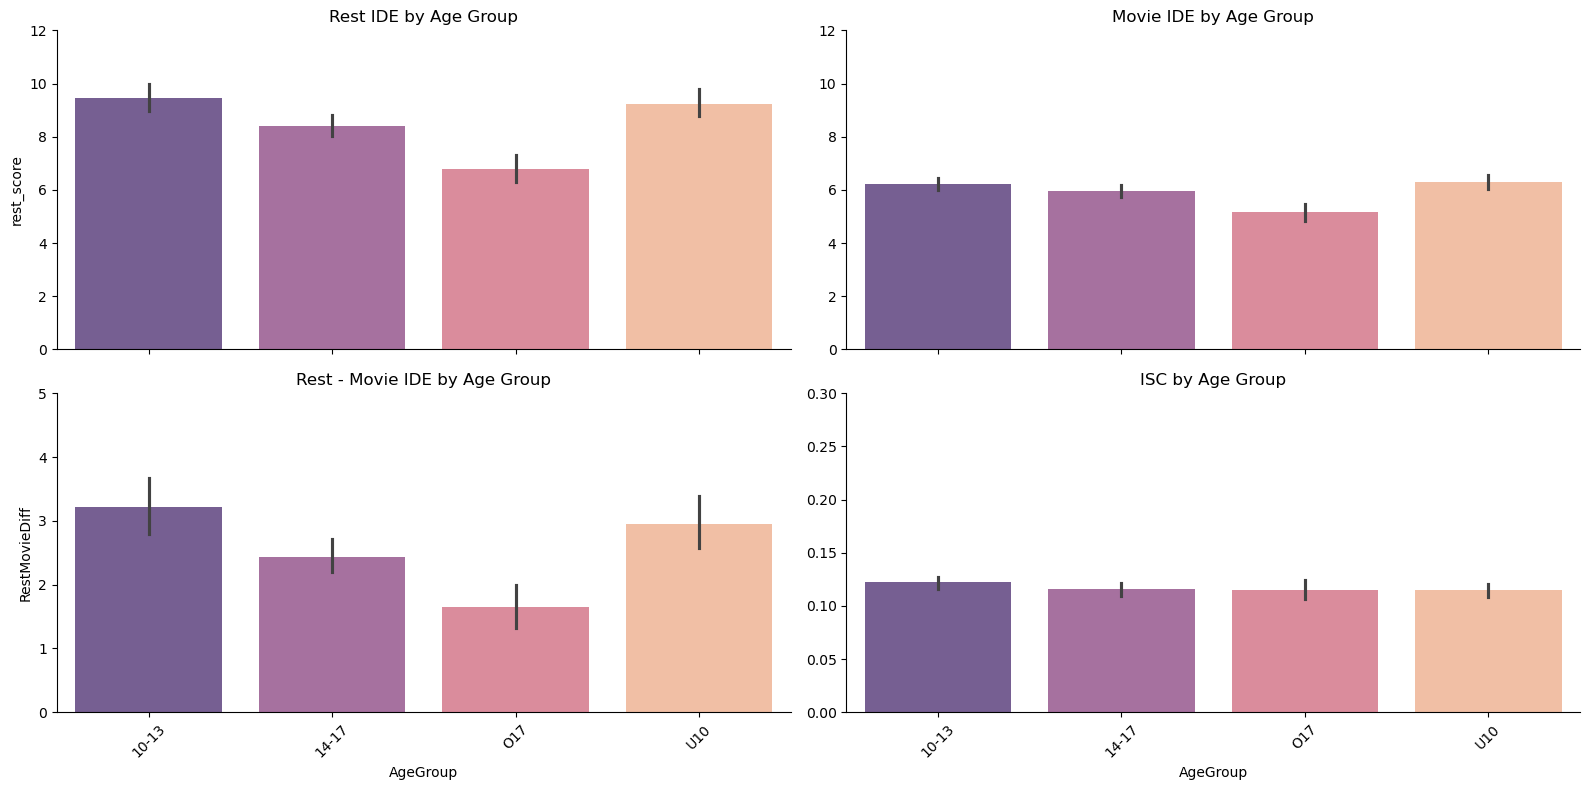

In [17]:
df1_hbn = difference_df.groupby(['subject_id', 'AgeGroup']).mean(numeric_only=True).reset_index()
fig, ax = plt.subplots(2, 2, figsize=(16, 8), sharex=True)
ax = ax.ravel()
age_order_orig = sorted(df1_hbn['AgeGroup'].unique())
for i, (col, title, ylim) in enumerate([
    ('rest_score', 'Rest IDE by Age Group', (0, 12)),
    ('movie_score', 'Movie IDE by Age Group', (0, 12)),
    ('RestMovieDiff', 'Rest - Movie IDE by Age Group', (0, 5)),
    ('ISC', 'ISC by Age Group', (0, 0.3))
]):
    g = sns.barplot(x='AgeGroup', y=col, data=df1_hbn, palette='magma', alpha=0.7,
                    order=age_order_orig, ax=ax[i])
    g.set(title=title, ylim=ylim, ylabel=col if i % 2 == 0 else '')
ax[2].tick_params(axis='x', rotation=45); ax[3].tick_params(axis='x', rotation=45)
sns.despine(); plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/hbn_avg_isc_ide_restmovediff_barplots.pdf', format='pdf', transparent=True)
plt.show()

## Parcelwise regressions: ISC ~ Age, movie IDE ~ Age, rest IDE ~ Age, RestMovieDiff ~ Age

In [18]:
# Uses parcelwise_regressions.run_regression_analyses (OLS per parcel + FDR correction)
temp1_hbn = difference_df.copy()
temp1_hbn['log_age'] = np.log(temp1_hbn['Age'] + 1)
regression_specs = [
    ("ISC", "ISC ~ Age + sex + session + movie_FD", ['movie_FD', 'ISC', 'sex', 'session', 'Age'],
     'hbn_isc_age_coef_surface.pdf', ['Age']),
    ("movie_score", "movie_score ~ Age + ISC + sex + session + movie_FD", ['ISC', 'movie_FD', 'sex', 'session', 'Age'],
     'hbn_movie_ide_age_coef_surface.pdf', ['Age', 'ISC']),
    ("rest_score", "rest_score ~ Age + sex + session + rest_FD", ['rest_FD', 'sex', 'session', 'Age'],
     'hbn_rest_ide_age_coef_surface.pdf', ['Age']),
    ("RestMovieDiff", "RestMovieDiff ~ Age + ISC + sex + session + movie_FD + rest_FD",
     ['movie_FD', 'ISC', 'rest_FD', 'sex', 'session', 'Age'],
     'hbn_restmovediff_age_coef_surface.pdf', ['Age', 'ISC']),
    ("RestMovieDiff", "RestMovieDiff ~ log_age + ISC + sex + session + movie_FD + rest_FD",
     ['movie_FD', 'ISC', 'rest_FD', 'sex', 'session', 'log_age'],
     'hbn_restmovediff_log_age_coef_surface.pdf', ['log_age', 'ISC']),
]

for yname, formula, covariates, outfn, to_plot in regression_specs:
    print(f"Running regression: {formula}")
    results_reg = pwr.run_regression_analyses(
        temp1_hbn, 'Age', yname, formula, covariates,
        output_directory=None, root_filename=None, region_order=REGION_ORDER_HBN,
        title='', plot=0, verbose=0)
    for var in to_plot:
        sig_mask = results_reg.set_index('region_name').reindex(REGION_ORDER_HBN)[f'sig_{var}_fdr'].values
        coef_masked = results_reg.set_index('region_name').reindex(REGION_ORDER_HBN)[f'coef_{var}'].values * sig_mask
        cbar_range, this_cmap = helper.determine_colorbar_range(coef_masked, helper.diverging_colormap_gpu(), symmetric=True)
        fn = outfn.replace('coef_surface', f'{var.lower()}_coef_surface')
        helper.generate_surface_plot(
            coef_masked, image_fn=f'{PLOT_DIR}/{fn}',
            atlas='Schaefer', cmap=this_cmap, cbar_range=cbar_range,
            surf_type='fslr', target_density='32k', method='linear',
            include_cbar=True, title=rf'$\beta$_{var} ({yname})', threshold=None, mask_medial_wall=True
        )

Running regression: ISC ~ Age + sex + session + movie_FD
Using formula: ISC ~ Age + sex + session + movie_FD
[get_dataset_dir] Dataset found in /Users/elb/nilearn_data/schaefer_2018
Generated surface plot: compiled/plots/hbn_isc_age_age_coef_surface.pdf
Running regression: movie_score ~ Age + ISC + sex + session + movie_FD
Using formula: movie_score ~ Age + ISC + sex + session + movie_FD
[get_dataset_dir] Dataset found in /Users/elb/nilearn_data/schaefer_2018
Generated surface plot: compiled/plots/hbn_movie_ide_age_age_coef_surface.pdf
[get_dataset_dir] Dataset found in /Users/elb/nilearn_data/schaefer_2018
Generated surface plot: compiled/plots/hbn_movie_ide_age_isc_coef_surface.pdf
Running regression: rest_score ~ Age + sex + session + rest_FD
Using formula: rest_score ~ Age + sex + session + rest_FD
[get_dataset_dir] Dataset found in /Users/elb/nilearn_data/schaefer_2018
Generated surface plot: compiled/plots/hbn_rest_ide_age_age_coef_surface.pdf
Running regression: RestMovieDiff ~ 

## ISC-IDE correlation by fine-grained AgeGroup + scatter vs Age

In [20]:
df_corr_hbn

,dataset,participant_id,modality,zscore,age_months,FD,zscore_zscored
0,HBN,sub-NDARAA948VFH,AV,6.702090,95.791920,0.100560,-0.134026
1,HBN,sub-NDARAB458VK9,AV,5.611607,154.034220,0.152709,-0.510681
2,HBN,sub-NDARAB977GFB,AV,8.660896,101.467488,0.188824,0.542551
3,HBN,sub-NDARAC331VEH,AV,10.974880,170.008212,0.093493,1.341807
4,HBN,sub-NDARAC350BZ0,AV,5.708611,155.052696,0.236301,-0.477176
...,...,...,...,...,...,...,...
522,HBN,sub-NDARYX853TAX,AV,0.461937,105.901428,0.144868,-2.289390
523,HBN,sub-NDARZB517KTU,AV,6.962710,152.595480,0.158604,-0.044007
524,HBN,sub-NDARZE963MEU,AV,6.728111,183.938388,0.165737,-0.125038
525,HBN,sub-NDARZM903TNL,AV,9.094005,115.036272,0.150355,0.692148


ISC-IDE correlation computed for 527 HBN subjects


/var/folders/1f/s3_5gwyj4j3c18swys7lqz4w0000gn/T/ipykernel_62033/2784476080.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='AgeGroup2', y='zscore', data=df_corr_hbn, palette='magma', alpha=0.7,
/var/folders/1f/s3_5gwyj4j3c18swys7lqz4w0000gn/T/ipykernel_62033/2784476080.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x='AgeGroup2', y='zscore', data=df_corr_hbn, palette='magma', size=5, alpha=1,


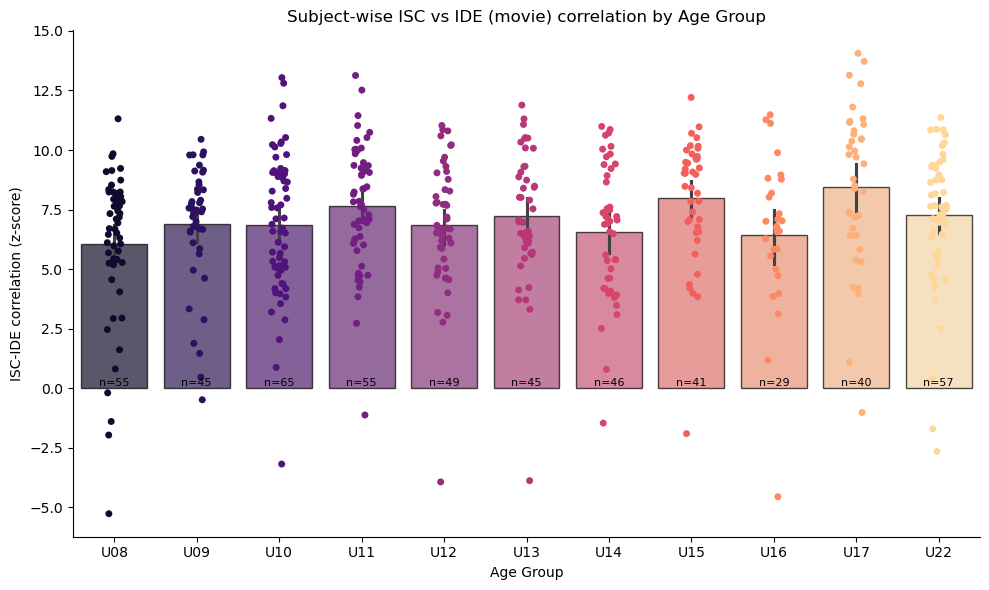

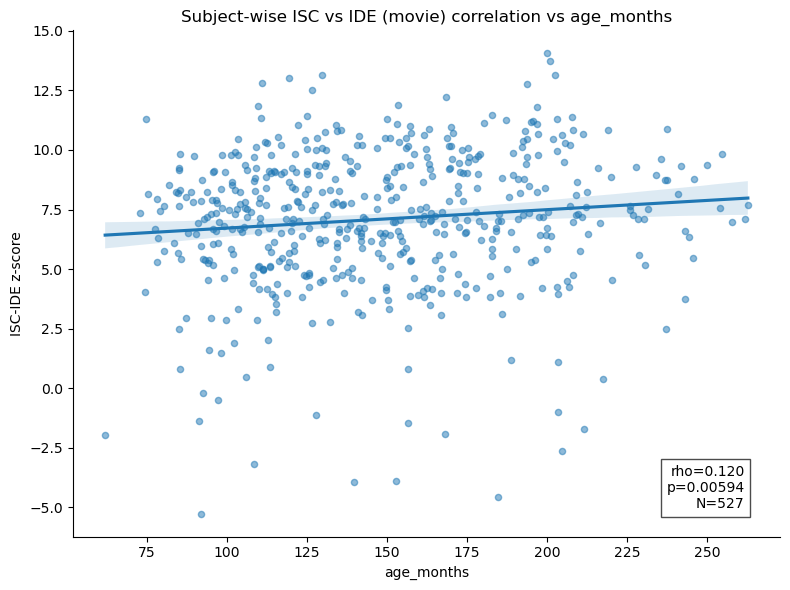

: 

In [ ]:
# INPUT: compiled/results/combined_corrs.csv (see REPRODUCIBILITY.md)
df_corr_hbn = pd.read_csv('compiled/results/combined_corrs.csv')
df_corr_hbn = df_corr_hbn[df_corr_hbn['dataset'] == 'HBN'].reset_index(drop=True)
print(f"ISC-IDE correlation computed for {len(df_corr_hbn)} HBN subjects")

def get_age_groupings_hbn_fine(age):
    age_y = age / 12
    if age_y < 8: return 'U08'
    if age_y < 9: return 'U09'
    if age_y < 10: return 'U10'
    if age_y < 11: return 'U11'
    if age_y < 12: return 'U12'
    if age_y < 13: return 'U13'
    if age_y < 14: return 'U14'
    if age_y < 15: return 'U15'
    if age_y < 16: return 'U16'
    if age_y < 17: return 'U17'
    return 'U22'

df_corr_hbn['AgeGroup2'] = [get_age_groupings_hbn_fine(a) for a in df_corr_hbn['age_months'].astype(float)]
age_order_hbn_fine = ['U08', 'U09', 'U10', 'U11', 'U12', 'U13', 'U14', 'U15', 'U16', 'U17', 'U22']
age_group_counts_hbn = df_corr_hbn['AgeGroup2'].value_counts().to_dict()

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x='AgeGroup2', y='zscore', data=df_corr_hbn, palette='magma', alpha=0.7,
            order=age_order_hbn_fine, ax=ax, edgecolor='black')
sns.stripplot(x='AgeGroup2', y='zscore', data=df_corr_hbn, palette='magma', size=5, alpha=1,
              order=age_order_hbn_fine, ax=ax)
for p, age_group in zip(ax.patches, age_order_hbn_fine):
    count = age_group_counts_hbn.get(age_group, 0)
    ax.text(p.get_x() + p.get_width() / 2., 0.01, f'n={count}', ha="center", va="bottom", fontsize=8)
ax.set_xlabel('Age Group'); ax.set_ylabel('ISC-IDE correlation (z-score)')
ax.set_title('Subject-wise ISC vs IDE (movie) correlation by Age Group')
sns.despine(); plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/hbn_isc_ide_corr_by_agegroup.pdf', format='pdf', transparent=True)
plt.show()

plt.figure(figsize=(8, 6))
sns.regplot(x='age_months', y='zscore', data=df_corr_hbn, scatter_kws={'s': 20, 'alpha': 0.5})
rho, p = scipy.stats.spearmanr(df_corr_hbn['age_months'].astype(float), df_corr_hbn['zscore'].astype(float), nan_policy='omit')
plt.gca().text(0.95, 0.05, f'rho={rho:.3f}\np={p:.3g}\nN={len(df_corr_hbn)}',
               transform=plt.gca().transAxes, ha='right', va='bottom',
               bbox=dict(facecolor='white', alpha=0.7))
plt.title('Subject-wise ISC vs IDE (movie) correlation vs age_months')
plt.xlabel('age_months'); plt.ylabel('ISC-IDE z-score')
sns.despine(); plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/hbn_isc_ide_corr_vs_age_scatter.pdf', format='pdf', transparent=True)
plt.show()